In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
import astropy.units as u
import afterglowpy as grb

day = 86400.0  # convert to seconds
jetType = 2
specType = 0
z = 0.0099
DOF = 35


flat_samples = np.loadtxt('Paralist.txt')
chi2_samples = np.loadtxt('M_chi2.txt')
quantiles_low = np.percentile(flat_samples, 16, axis=0)
quantiles_high = np.percentile(flat_samples, 84, axis=0)
mask = np.all((flat_samples >= quantiles_low) & (flat_samples <= quantiles_high), axis=1)
paras_subset_1sigma = flat_samples[mask]
chi2_subset_1sigma = chi2_samples[mask]
mask1=np.argmin(chi2_subset_1sigma)
chi2_min = np.min(chi2_subset_1sigma)
theta_best=paras_subset_1sigma[mask1]
print(chi2_min)
delt_chi2 = chi2_subset_1sigma-chi2_min
delt_crit = chi2.ppf(0.68, DOF)
mask2 = (delt_chi2<=delt_crit)
paras_subset_final = paras_subset_1sigma[mask2]
# print(len(paras_subset_final))

79.66755140713161


In [5]:
def model(x, thV, thC, log_ee, log_eb, log_E0, log_n0):
    epse = 10.**(log_ee)
    epsB = 10.**(log_eb)
    E0 = 10.0**log_E0
    n0 = 10.**(log_n0)
    if epsB <= 0 or epsB > 1 or epse <= 0 or epse > 1:
        return np.full(x.shape[1], np.nan)

    #  fixed parameters
    Z = {
        'jetType': jetType,
        'specType': specType,
        'thetaObs': thV,
        'E0': E0,
        'thetaCore': thC,
        'thetaWing': 15. / 180. * np.pi,
        'n0': n0,
        'p': 2.1,
        'epsilon_e': epse,
        'epsilon_B': epsB,
        'xi_N': 1.0,
        'd_L': 1.23e26,
        'z': z
    }

    t_day, frequency = x
    t_seconds = t_day * day
    return grb.fluxDensity(t_seconds, frequency, **Z)

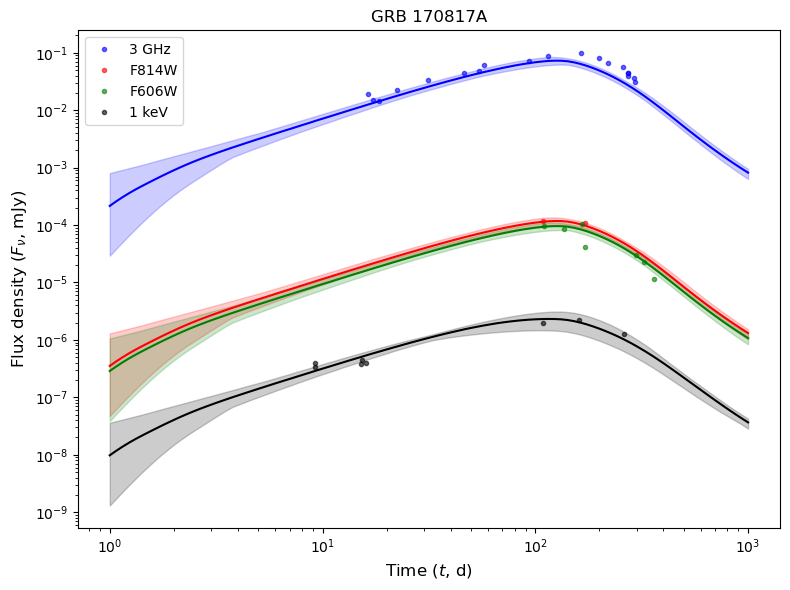

In [14]:
t_xray, f_xray = np.loadtxt('x_ray.txt', usecols=(0, 1), unpack=True)
t_radio, f_radio = np.loadtxt('radio.txt', usecols=(0, 1), unpack=True)
t_f814w, f_f814w = np.loadtxt('f814w.txt', usecols=(0, 1), unpack=True)
t_f606w, f_f606w = np.loadtxt('f606w.txt', usecols=(0, 1), unpack=True)

nu_radio = np.full(t_radio.shape, 3.0e9)  # 3 GHz
nu_f814w = np.full(t_f814w.shape, (8369.51 * u.Angstrom).to(u.Hz, equivalencies=u.spectral()).value)
nu_f606w = np.full(t_f606w.shape, (5778.32 * u.Angstrom).to(u.Hz, equivalencies=u.spectral()).value)
nu_X = np.full(t_xray.shape, (1. * u.keV).to(u.Hz, equivalencies=u.spectral()).value)

all_time = np.concatenate((t_radio, t_f814w, t_f606w, t_xray), axis=None)
all_freq = np.concatenate((nu_radio, nu_f814w, nu_f606w, nu_X), axis=None)
x = np.row_stack([all_time, all_freq])
y = np.concatenate((f_radio, f_f814w, f_f606w, f_xray), axis=None)
mask = np.linspace(0, len(paras_subset_final)-1, 100).astype(int)
t_theo = np.logspace(np.log10(1.0), np.log10(1000.0), num=100)*day
nu_arr = [
    3.0e9,
    (8369.51 * u.Angstrom).to(u.Hz, equivalencies=u.spectral()).value,
    (5778.32 * u.Angstrom).to(u.Hz, equivalencies=u.spectral()).value,
    (1. * u.keV).to(u.Hz, equivalencies=u.spectral()).value
]
labels = ['3 GHz', 'F814W', 'F606W', '1 keV']
colors = ['blue', 'red', 'green', 'black']

Fnu_theo = []
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_title('GRB 170817A')
for i in range(4):
    radiation_values = []
    x_theo = np.row_stack([t_theo / day, np.full_like(t_theo, nu_arr[i])])
    Fnu = model(x_theo, *theta_best)
    for j, theta in enumerate(paras_subset_final[mask]):
        radiation_values.append(model(x_theo, *theta))
    rad_upper = np.max(radiation_values, axis=0)
    rad_lower = np.min(radiation_values, axis=0)
    Fnu_theo.append(Fnu)
    ax.plot(t_theo / day, Fnu_theo[i], color=colors[i])
    ax.fill_between(
        t_theo / day,
        rad_lower,
        rad_upper,
        color=colors[i],
        alpha=0.2,
    )

ax.plot(t_radio, f_radio, '.', color=colors[0], alpha=0.6, label=labels[0])
ax.plot(t_f814w, f_f814w, '.', color=colors[1], alpha=0.6, label=labels[1])
ax.plot(t_f606w, f_f606w, '.', color=colors[2], alpha=0.6, label=labels[2])
ax.plot(t_xray, f_xray, '.', color=colors[3], alpha=0.6, label=labels[3])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Time ($t$, d)', fontsize=12)
ax.set_ylabel(r'Flux density ($F_\nu$, mJy)', fontsize=12)
ax.legend(loc='best')
plt.tight_layout()
plt.legend()
plt.savefig("mcmc_fit_shaded.png", dpi=300)
plt.show()